In [111]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [112]:
data=pd.read_csv('/content/scr-dataset.csv')

In [113]:
print(data.head())


     x         y
0  1.0  1.750768
1  1.1  1.699704
2  1.2  1.607502
3  1.3  1.479060
4  1.4  1.320438


In [114]:
print('check null:')
print(data.isnull().sum())

check null:
x    0
y    0
dtype: int64


In [115]:
x=data['x'].values
y=data['y'].values

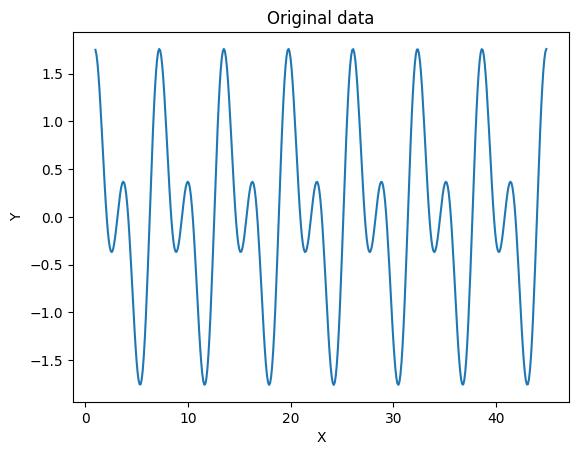

In [116]:
plt.plot(x,y)
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Original data')
plt.show()

In [117]:
from scipy.optimize import curve_fit
from scipy.fft import fft,fftfreq
from sklearn.metrics import mean_squared_error,r2_score

In [118]:
#FFT (Fast Fourier Transform) analysis
N=len(x)
T=(max(x)-min(x))/N
yf=fft(y)
xf=fftfreq(N,T)[:N//2]
amplitude_spectrum=2.0/N * np.abs(yf[:N//2])

In [119]:
print(f'Frequency (cycles per x unit) = {yf[:5]}')
print(f'Amplitude = {amplitude_spectrum[:5]}')

Frequency (cycles per x unit) = [0.31171386-0.j         0.31565016-0.00825266j 0.32834098-0.01816562j
 0.35306273-0.03229581j 0.39843611-0.05615231j]
Amplitude = [0.00141688 0.00143526 0.00149474 0.00161153 0.00182897]


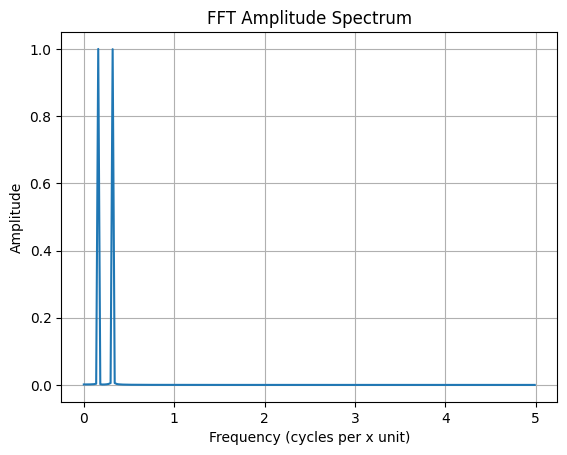

In [120]:
plt.plot(xf,amplitude_spectrum)
plt.xlabel('Frequency (cycles per x unit)')
plt.ylabel('Amplitude')
plt.title('FFT Amplitude Spectrum')
plt.grid(True)
plt.show()

Top frequency components identified from FFT:
Component 1: Frequency = 0.159453, Amplitude = 1.000778
Component 2: Frequency = 0.318907, Amplitude = 1.000002
Top frequency components identified from FFT:
Component 1: Frequency = 0.159453, Amplitude = 1.000778
Component 2: Frequency = 0.318907, Amplitude = 1.000002


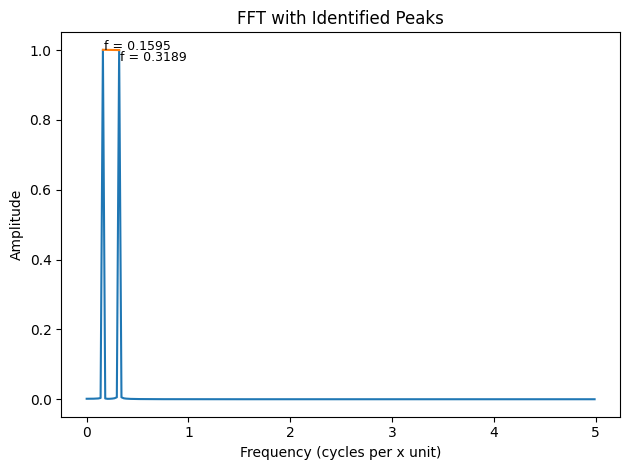

In [138]:
# peaks in the frequency spectrum
from scipy.signal import find_peaks

peaks,_=find_peaks(amplitude_spectrum,height=0.1)
peak_frequency = xf[peaks]
peak_amplitudes = amplitude_spectrum[peaks]

#sort peaks by amplitude
if len(peaks)>0:
  sorted_indices=np.argsort(peak_amplitudes)[::-1]
  peak_frequency=peak_frequency[sorted_indices]
  peak_amplitudes=peak_amplitudes[sorted_indices]


  plt.plot(xf, amplitude_spectrum)
  plt.plot(peak_frequency,peak_amplitudes)
  for i,(f,a) in enumerate(zip(peak_frequency,peak_amplitudes)):
    if i < 3:
      plt.text(f + 0.01, a - i*0.03, f'f = {f:.4f}', fontsize=9)

    print("Top frequency components identified from FFT:")
    for i,(f,a) in enumerate(zip(peak_frequency,peak_amplitudes)):
      if i < 5:
        print(f"Component {i+1}: Frequency = {f:.6f}, Amplitude = {a:.6f}")

else:
  print("No significant peaks found in FFT. Using default frequency estimates.")
  plt.plot(xf, amplitude_spectrum)
  plt.title('FFT (No significant peaks found)')

plt.title('FFT with Identified Peaks')
plt.xlabel('Frequency (cycles per x unit)')
plt.ylabel('Amplitude')
# plt.grid(True)
plt.tight_layout()


In [122]:
def harmonic_model(x, a1, f1, p1, a2, f2, p2, offset):
    """
    a1*sin(2π*f1*x + p1) + a2*sin(2π*f2*x + p2) + offset
    """
    return (a1 * np.sin(2 * np.pi * f1 * x + p1) +
            a2 * np.sin(2 * np.pi * f2 * x + p2) + offset)


In [123]:
y_range = np.max(y) - np.min(y)
y_mean = np.mean(y)
x_range = max(x) - min(x)

default_f1 = 0.167  # Primary frequency estimate
default_f2 = 0.333  # Second harmonic

In [124]:
# Set initial guesses
if len(peak_frequency) >= 2:
    #  found peaks in the FFT
    f1_init = peak_frequency[0]
    f2_init = peak_frequency[1]
    a1_init = peak_amplitudes[0] * 2
    a2_init = peak_amplitudes[1] * 2
else:
    # If no clear peaks then default estimates
    f1_init = default_f1
    f2_init = default_f2
    a1_init = y_range * 0.6
    a2_init = y_range * 0.2


# Initial parameter guesses
initial_guess = [
    a1_init,     # a1: amplitude of first component
    f1_init,     # f1: primary frequency
    0.0,         # p1: phase of first component (start with 0)
    a2_init,     # a2: amplitude of second component
    f2_init,     # f2: second frequency
    0.0,         # p2: phase of second component (start with 0)
    y_mean       # offset: vertical shift (start with mean of y)
]

In [125]:
# Set bounds for the parameters to help convergence
# Lower bounds
lb = [0.0,            # a1: min amplitude (must be positive)
      0.05,           # f1: min frequency (very slow oscillation)
      -2*np.pi,       # p1: phase can be anything in -2π to 2π
      0.0,            # a2: min amplitude (must be positive)
      0.05,           # f2: min frequency
      -2*np.pi,       # p2: phase can be anything in -2π to 2π
      y_mean - y_range/2]  # offset: can be around the data mean

# Upper bounds
ub = [y_range * 1.5,  # a1: max amplitude (1.5x the data range)
      0.5,            # f1: max frequency (faster than we expect)
      2*np.pi,        # p1: phase upper bound
      y_range * 1.5,  # a2: max amplitude
      1.0,            # f2: max frequency (faster than we expect)
      2*np.pi,        # p2: phase upper bound
      y_mean + y_range/2]  # offset: can be around the data mean

In [126]:
print("\nParameter bounds and initial guesses:")
param_names = ["a1", "f1", "p1", "a2", "f2", "p2", "offset"]
for i, name in enumerate(param_names):
    print(f"{name}: bounds=[{lb[i]:.4f}, {ub[i]:.4f}], initial={initial_guess[i]:.4f}")

    # Verify that initial guess is within bounds
    if not (lb[i] <= initial_guess[i] <= ub[i]):
        print(f"Initial guess for {name} is outside bounds!")
        # Adjust the initial guess to be within bounds
        initial_guess[i] = min(max(initial_guess[i], lb[i]), ub[i])
        print(f"  Adjusted to: {initial_guess[i]:.4f}")


Parameter bounds and initial guesses:
a1: bounds=[0.0000, 5.2805], initial=2.0016
f1: bounds=[0.0500, 0.5000], initial=0.1595
p1: bounds=[-6.2832, 6.2832], initial=0.0000
a2: bounds=[0.0000, 5.2805], initial=2.0000
f2: bounds=[0.0500, 1.0000], initial=0.3189
p2: bounds=[-6.2832, 6.2832], initial=0.0000
offset: bounds=[-1.7594, 1.7609], initial=0.0007


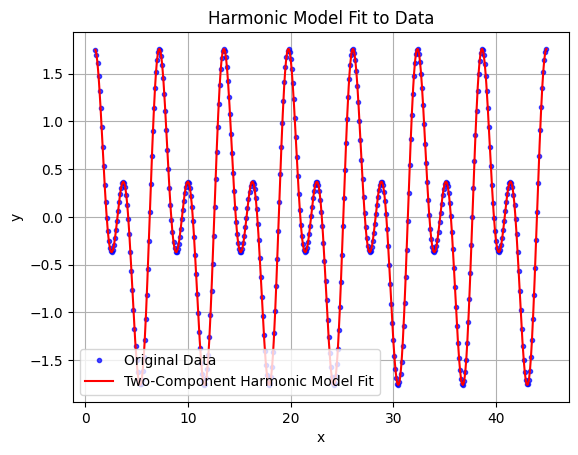

In [127]:
# Fit the harmonic model to the data
try:
    popt, pcov = curve_fit(
        harmonic_model,
        x,
        y,
        p0=initial_guess,
        bounds=(lb, ub),
        maxfev=20000  # Increase maximum function evaluations
    )
    a1_opt, f1_opt, p1_opt, a2_opt, f2_opt, p2_opt, offset_opt = popt

    # Generate predictions using the fitted model
    y_pred = harmonic_model(x, *popt)

    mse = mean_squared_error(y, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y, y_pred)

    x_smooth = np.linspace(min(x), max(x), 1000)
    y_smooth = harmonic_model(x_smooth, *popt)

    plt.plot(x, y, 'b.', alpha=0.7, label='Original Data')
    plt.plot(x_smooth, y_smooth, 'r-', label='Two-Component Harmonic Model Fit')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.title('Harmonic Model Fit to Data')
    plt.legend()
    plt.grid(True)
except Exception as e:
    print(f"Error during curve fitting: {e}")
    import traceback
    traceback.print_exc()

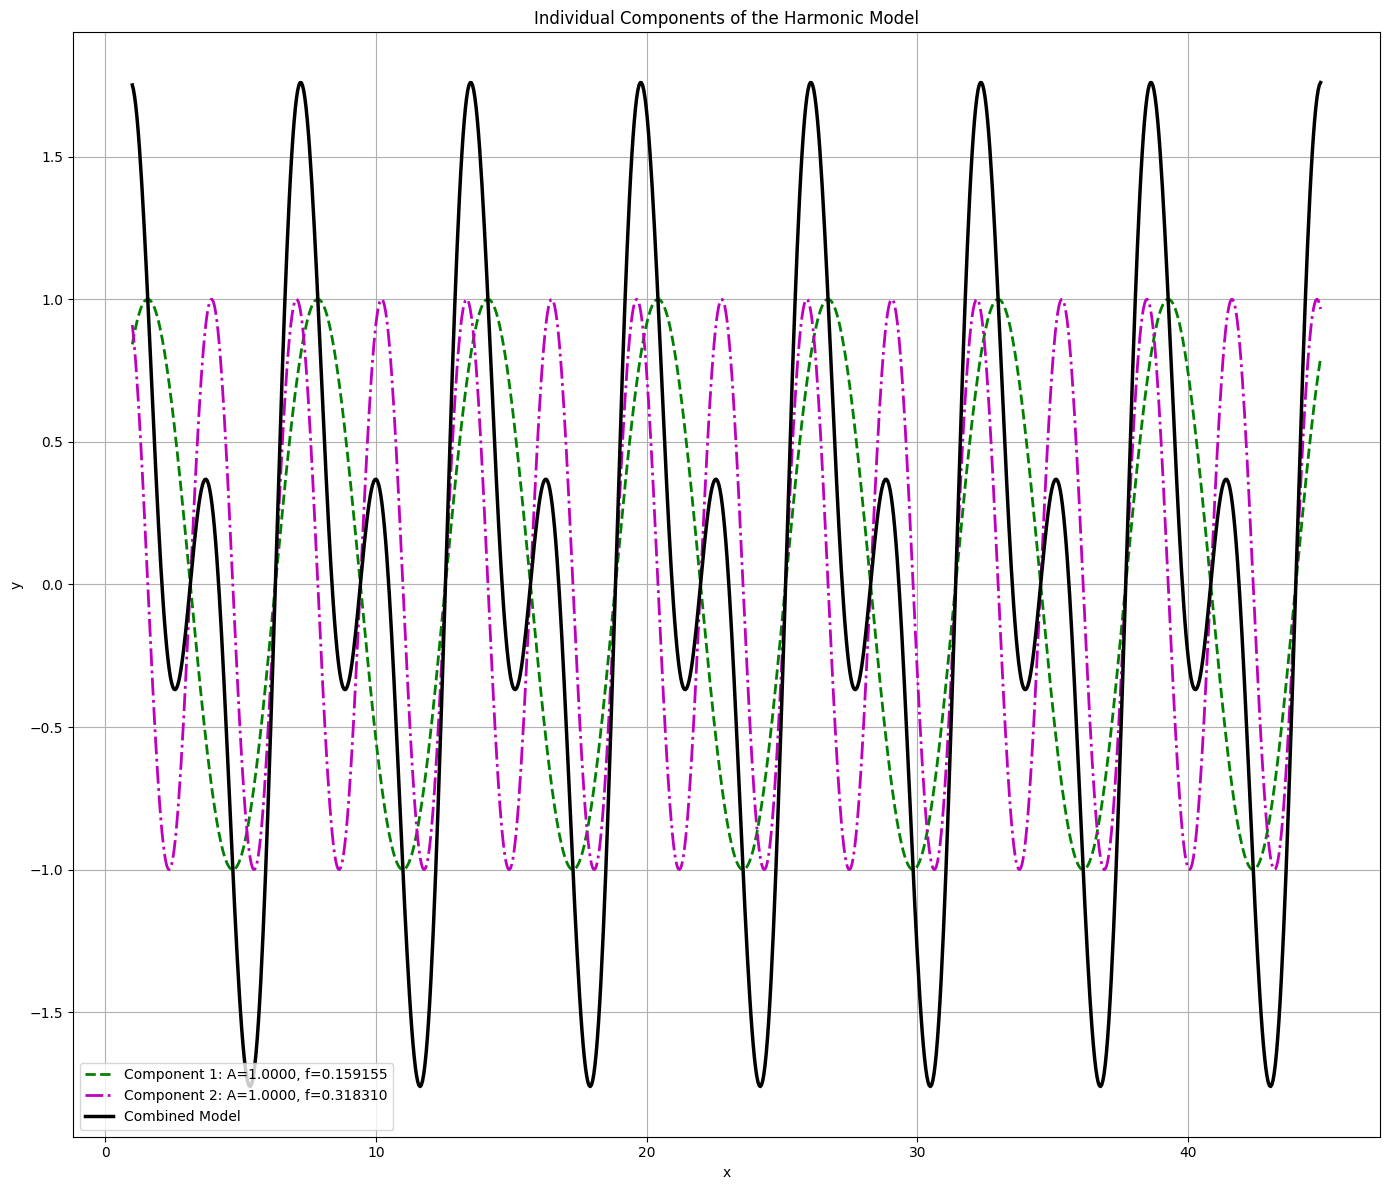

In [128]:
# Individual components
comp1 = a1_opt * np.sin(2 * np.pi * f1_opt * x_smooth + p1_opt)
comp2 = a2_opt * np.sin(2 * np.pi * f2_opt * x_smooth + p2_opt)

plt.figure(figsize=(14, 12))

# Use different linestyles and colors
plt.plot(x_smooth, comp1, 'g--', linewidth=2, label=f'Component 1: A={a1_opt:.4f}, f={f1_opt:.6f}')
plt.plot(x_smooth, comp2, 'm-.', linewidth=2, label=f'Component 2: A={a2_opt:.4f}, f={f2_opt:.6f}')
plt.plot(x_smooth, comp1 + comp2 + offset_opt, 'k-', linewidth=2.5, label='Combined Model')

plt.xlabel('x')
plt.ylabel('y')
plt.title('Individual Components of the Harmonic Model')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [129]:
print("\nTwo-Component Harmonic Model Parameters:")
print(f"Component 1: Amplitude={a1_opt:.4f}, Frequency={f1_opt:.6f}, Period={1/f1_opt:.4f}, Phase={p1_opt:.4f}")
print(f"Component 2: Amplitude={a2_opt:.4f}, Frequency={f2_opt:.6f}, Period={1/f2_opt:.4f}, Phase={p2_opt:.4f}")
print(f"Offset: {offset_opt:.4f}")
print(f"\nModel equation:")
print(f"y(x) = {a1_opt:.4f}*sin(2π*{f1_opt:.6f}*x + {p1_opt:.4f}) + "
          f"{a2_opt:.4f}*sin(2π*{f2_opt:.6f}*x + {p2_opt:.4f}) + {offset_opt:.4f}")
print(f"\nPerformance Metrics:")
print(f"RMSE: {rmse:.6f}")
print(f"R²: {r2:.6f}")



Two-Component Harmonic Model Parameters:
Component 1: Amplitude=1.0000, Frequency=0.159155, Period=6.2832, Phase=0.0000
Component 2: Amplitude=1.0000, Frequency=0.318310, Period=3.1416, Phase=0.0000
Offset: 0.0000

Model equation:
y(x) = 1.0000*sin(2π*0.159155*x + 0.0000) + 1.0000*sin(2π*0.318310*x + 0.0000) + 0.0000

Performance Metrics:
RMSE: 0.000000
R²: 1.000000


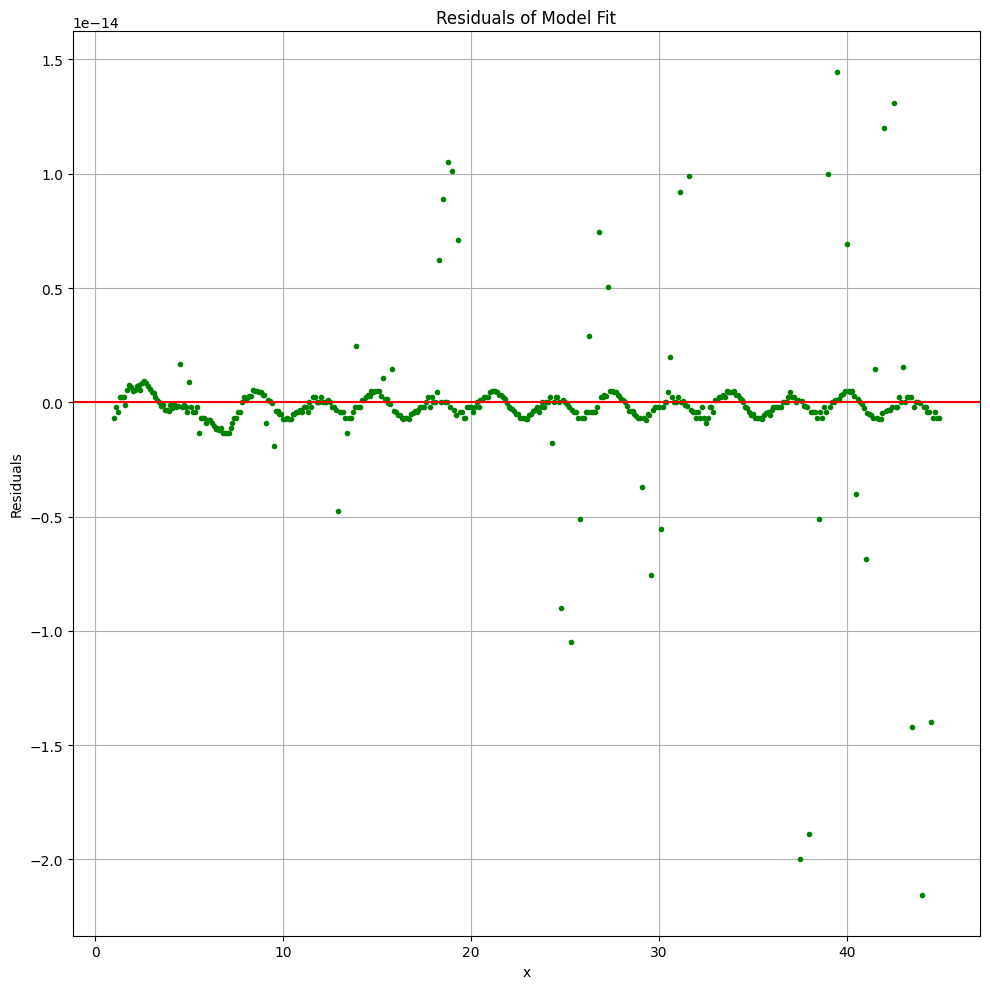

In [130]:
#  Residuals:residual is the difference between the actual data and the predicted values
plt.figure(figsize=(10, 10))
residuals = y - y_pred
plt.plot(x, residuals, 'g.')
plt.axhline(y=0, color='r', linestyle='-')
plt.xlabel('x')
plt.ylabel('Residuals')
plt.title('Residuals of Model Fit')
plt.grid(True)

plt.tight_layout()


In [131]:
# Make predictions for future values
x_future = np.arange(max(x) + 0.1, 60.1, 0.1)  # Extend to x=60 to include x=50
y_future = harmonic_model(x_future, *popt)

In [132]:
x_50_index = np.where(np.isclose(x_future, 50.0))[0]
if len(x_50_index) > 0:
  y_50 = y_future[x_50_index[0]]
  print(f"\nPrediction at x=50: y = {y_50:.6f}")


Prediction at x=50: y = -0.768740


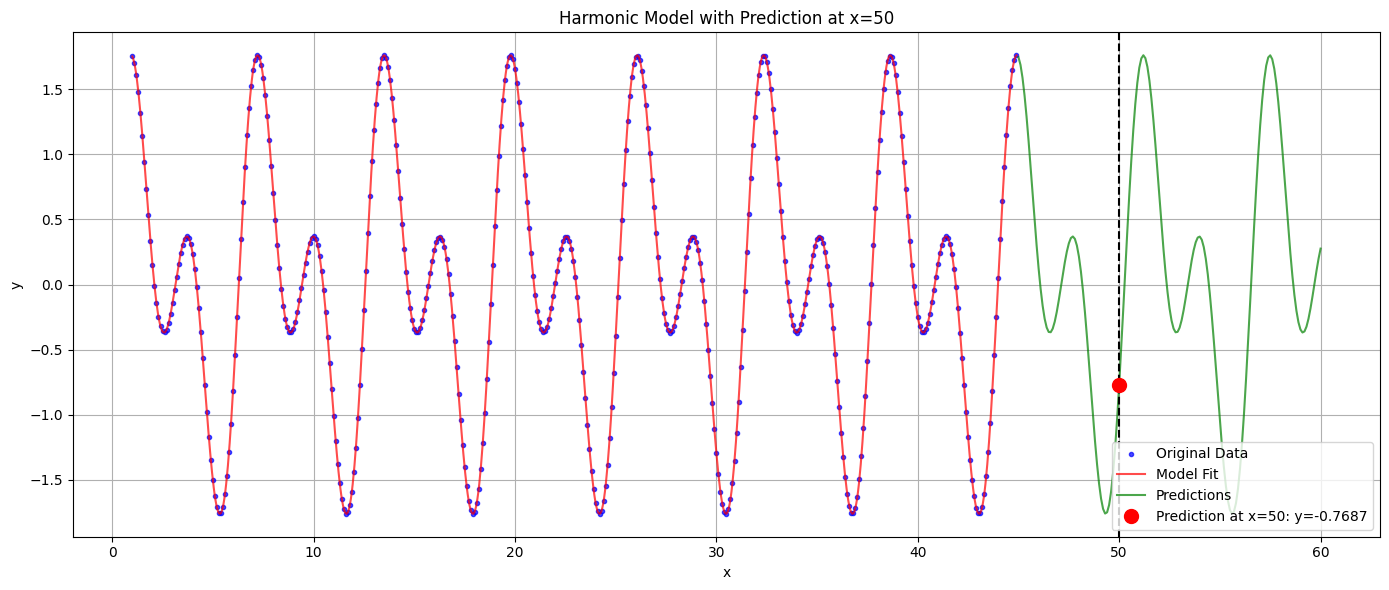

In [133]:
plt.figure(figsize=(14, 6))
plt.plot(x, y, 'b.', alpha=0.7, label='Original Data')
plt.plot(x_smooth, y_smooth, 'r-', alpha=0.7, label='Model Fit')
plt.plot(x_future, y_future, 'g-', alpha=0.7, label='Predictions')
plt.axvline(x=50, color='k', linestyle='--')
plt.plot(50, y_50, 'ro', markersize=10, label=f'Prediction at x=50: y={y_50:.4f}')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Harmonic Model with Prediction at x=50')
plt.legend()
plt.grid(True)
plt.tight_layout()